![insomnia](insomnia.jpg)


Your client, SleepInc, has shared anonymized sleep data from their hot new sleep tracking app SleepScope. As their data science consultant, your mission is to analyze the lifestyle survey data with Python to discover relationships between exercise, gender, occupation, and sleep quality. See if you can identify patterns leading to insights on sleep quality.

## 💾 The data: sleep_health_data.csv

SleepInc has provided you with an anonymized dataset of sleep and lifestyle metrics for 374 individuals. This dataset contains average values for each person calculated over the past six months. The data is saved as `sleep_health_data.csv`.

The dataset includes 13 columns covering sleep duration, quality, disorders, exercise, stress, diet, demographics, and other factors related to sleep health. 

| Column | Description |
|---------|----------------------------------------|  
| `Person ID` | An identifier for each individual. |
| `Gender` | The gender of the person (Male/Female). |  
| `Age` | The age of the person in years. |
| `Occupation` | The occupation or profession of the person. |
| `Sleep Duration (hours)` | The average number of hours the person sleeps per day. |
| `Quality of Sleep (scale: 1-10)` | A subjective rating of the quality of sleep, ranging from 1 to 10. |
| `Physical Activity Level (minutes/day)` | The average number of minutes the person engages in physical activity daily. |  
| `Stress Level (scale: 1-10)` | A subjective rating of the stress level experienced by the person, ranging from 1 to 10. |
| `BMI Category` | The BMI category of the person (e.g., Underweight, Normal, Overweight). |
| `Blood Pressure (systolic/diastolic)` | The average blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure. |
| `Heart Rate (bpm)` | The average resting heart rate of the person in beats per minute. |
| `Daily Steps` | The average number of steps the person takes per day. |
| `Sleep Disorder` | The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea). |

In [70]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

# Loading Dataset
sleep_health_data = pd.read_csv('sleep_health_data.csv')
print(sleep_health_data.head())

   Person ID Gender  Age  ... Heart Rate  Daily Steps  Sleep Disorder
0          1   Male   27  ...         77         4200            None
1          2   Male   28  ...         75        10000            None
2          3   Male   28  ...         75        10000            None
3          4   Male   28  ...         85         3000     Sleep Apnea
4          5   Male   28  ...         85         3000     Sleep Apnea

[5 rows x 13 columns]


In [71]:
# Understanding data
print("Data Info \n", sleep_health_data.info())
print("Data Description \n", sleep_health_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
Data Info 
 None
Data 

In [72]:
# Check for null values
sleep_health_data.isna().any()

Person ID                  False
Gender                     False
Age                        False
Occupation                 False
Sleep Duration             False
Quality of Sleep           False
Physical Activity Level    False
Stress Level               False
BMI Category               False
Blood Pressure             False
Heart Rate                 False
Daily Steps                False
Sleep Disorder             False
dtype: bool

In [73]:
lowest_sleep_occ_calc = sleep_health_data.groupby('Occupation')['Sleep Duration'].mean().round(2)
lowest_sleep_occ_sort = lowest_sleep_occ_calc.sort_values(ascending=True)

lowest_occ_name = lowest_sleep_occ_sort.index[0]
lowest_duration = lowest_sleep_occ_sort.iloc[0]

print(f"The occupation with the lowest average sleep duration is: {lowest_occ_name} with a duration of {lowest_duration:.2f} hours.")

print(lowest_sleep_occ_sort)

The occupation with the lowest average sleep duration is: Sales Representative with a duration of 5.90 hours.
Occupation
Sales Representative    5.90
Scientist               6.00
Salesperson             6.40
Teacher                 6.69
Software Engineer       6.75
Manager                 6.90
Doctor                  6.97
Nurse                   7.06
Accountant              7.11
Lawyer                  7.41
Engineer                7.99
Name: Sleep Duration, dtype: float64


In [74]:
# Find occupation with lowest sleep duration
lowest_sleep_occ = "Sales Representative"

In [75]:
lowest_sleep_quality_calc = sleep_health_data.groupby('Occupation')['Quality of Sleep'].mean().round(2)
lowest_sleep_quality_sort = lowest_sleep_quality_calc.sort_values(ascending=True)

lowest_occ_qual_name = lowest_sleep_quality_sort.index[0]
lowest_occ_qual_avg = lowest_sleep_quality_sort.iloc[0]

print(f"The occupation with the lowest average sleep quality is: {lowest_occ_qual_name} with an average of {lowest_occ_qual_avg:.2f} hours.")

print(lowest_sleep_quality_sort)

The occupation with the lowest average sleep quality is: Sales Representative with an average of 4.00 hours.
Occupation
Sales Representative    4.00
Scientist               5.00
Salesperson             6.00
Software Engineer       6.50
Doctor                  6.65
Teacher                 6.98
Manager                 7.00
Nurse                   7.37
Accountant              7.89
Lawyer                  7.89
Engineer                8.41
Name: Quality of Sleep, dtype: float64


In [76]:
lowest_sleep_quality_occ = "Sales Representative"

In [77]:
# Check if the same occupation has the lowest average sleep duration and quality
if lowest_occ_qual_name == lowest_occ_name:
    same_occ = True
else:
    same_occ = False

print(same_occ)

True


In [78]:
# Filter what ratio of app users in each BMI category have been diagnosed with Insomnia

normal_insomnia = sleep_health_data[(sleep_health_data['BMI Category'] == 'Normal') & (sleep_health_data['Sleep Disorder'] == 'Insomnia')]
overweight_insomnia = sleep_health_data[(sleep_health_data['BMI Category'] == 'Overweight') & (sleep_health_data['Sleep Disorder'] == 'Insomnia')]
obese_insomnia = sleep_health_data[(sleep_health_data['BMI Category'] == 'Obese') & (sleep_health_data['Sleep Disorder'] == 'Insomnia')]

print(normal_insomnia)
print(overweight_insomnia)
print(obese_insomnia)

     Person ID  Gender  Age  ... Heart Rate  Daily Steps  Sleep Disorder
18          19  Female   29  ...         80         4000        Insomnia
31          32  Female   30  ...         78         4100        Insomnia
67          68    Male   33  ...         72         5000        Insomnia
94          95  Female   36  ...         68         7000        Insomnia
146        147    Male   39  ...         68         8000        Insomnia
165        166    Male   41  ...         70         8000        Insomnia
201        202    Male   43  ...         70         8000        Insomnia
202        203    Male   43  ...         70         8000        Insomnia
315        316  Female   53  ...         65         5000        Insomnia

[9 rows x 13 columns]
     Person ID  Gender  Age  ... Heart Rate  Daily Steps  Sleep Disorder
105        106    Male   36  ...         74         4800        Insomnia
147        148    Male   39  ...         80         4000        Insomnia
177        178    Male   42 

In [79]:
total_bmi = sleep_health_data['BMI Category'].value_counts()

insomnia_filter = sleep_health_data[sleep_health_data['Sleep Disorder'] == 'Insomnia']

insomnia_by_bmi = insomnia_filter['BMI Category'].value_counts()

bmi_insomnia_ratio = (insomnia_by_bmi / total_bmi).round(2)

print(bmi_insomnia_ratio)

Normal        0.04
Obese         0.40
Overweight    0.43
Name: BMI Category, dtype: float64


In [80]:
bmi_insomnia_ratios = bmi_insomnia_ratio.to_dict()
print(bmi_insomnia_ratio)

Normal        0.04
Obese         0.40
Overweight    0.43
Name: BMI Category, dtype: float64


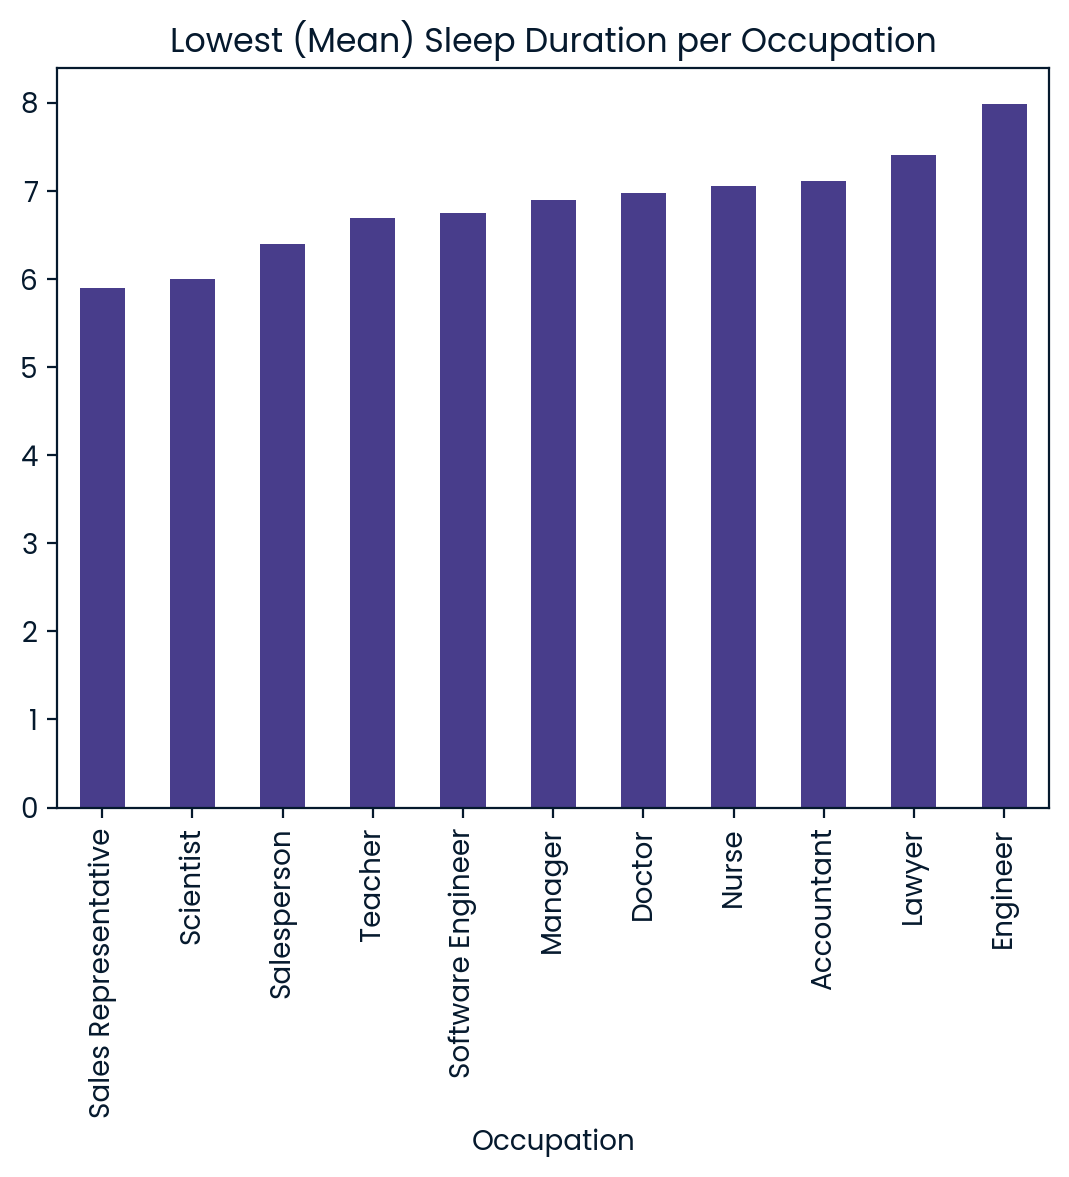

In [97]:
# Some Data Visualizations for fun - Part 1

lowest_sleep_occ_sort.plot(kind='bar', x='Occupation', y='Sleep Duration', title='Lowest (Mean) Sleep Duration per Occupation', color='darkslateblue')
plt.show()

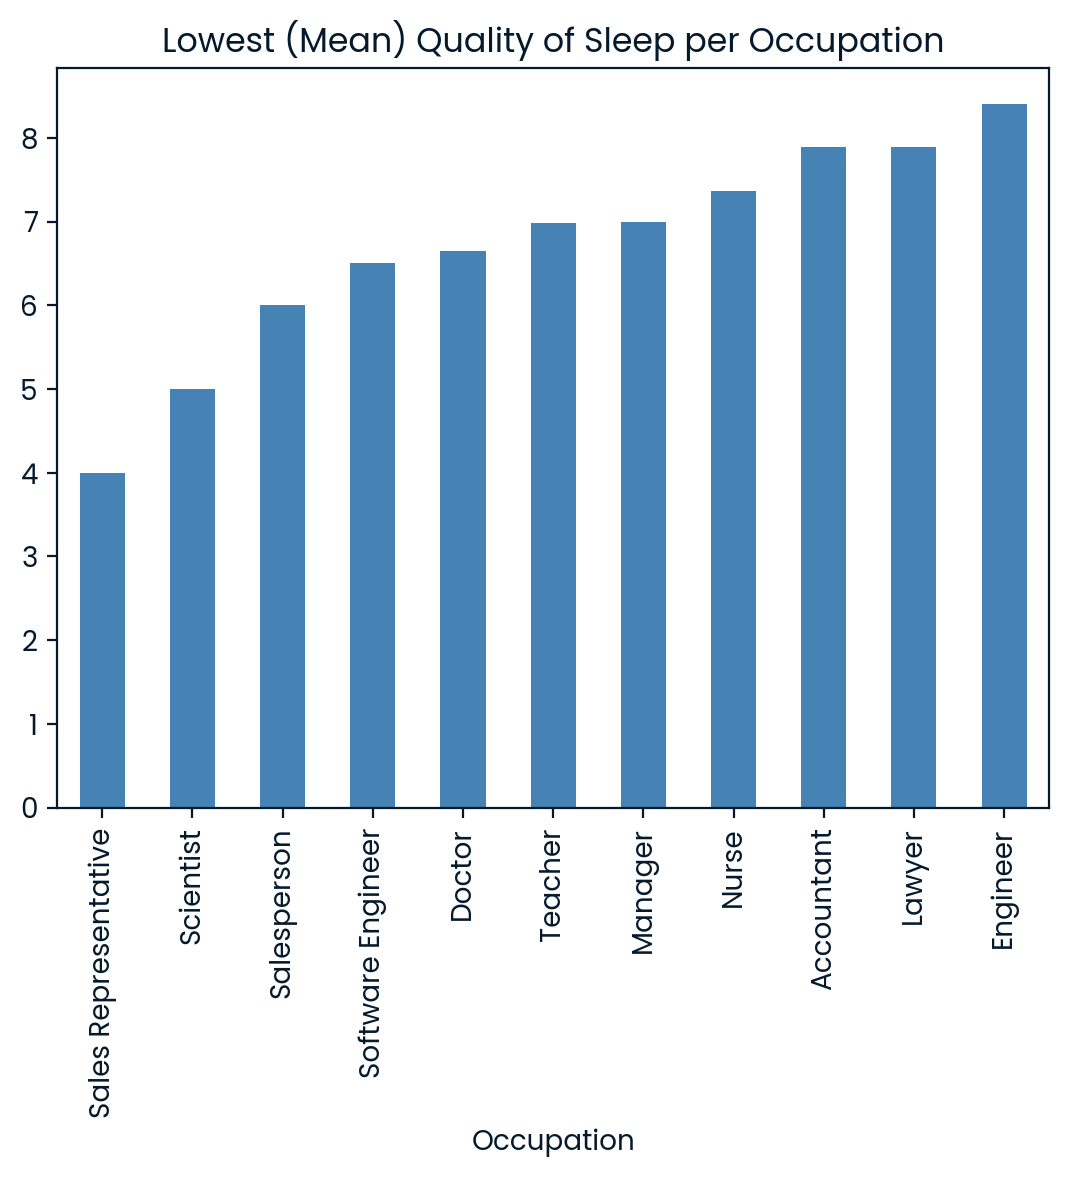

In [91]:
# Some Data Visualizations for fun - Part 2

lowest_sleep_quality_sort.plot(kind='bar', x='occupation', y='Quality of Sleep', title="Lowest (Mean) Quality of Sleep per Occupation", color='steelblue')
plt.show()

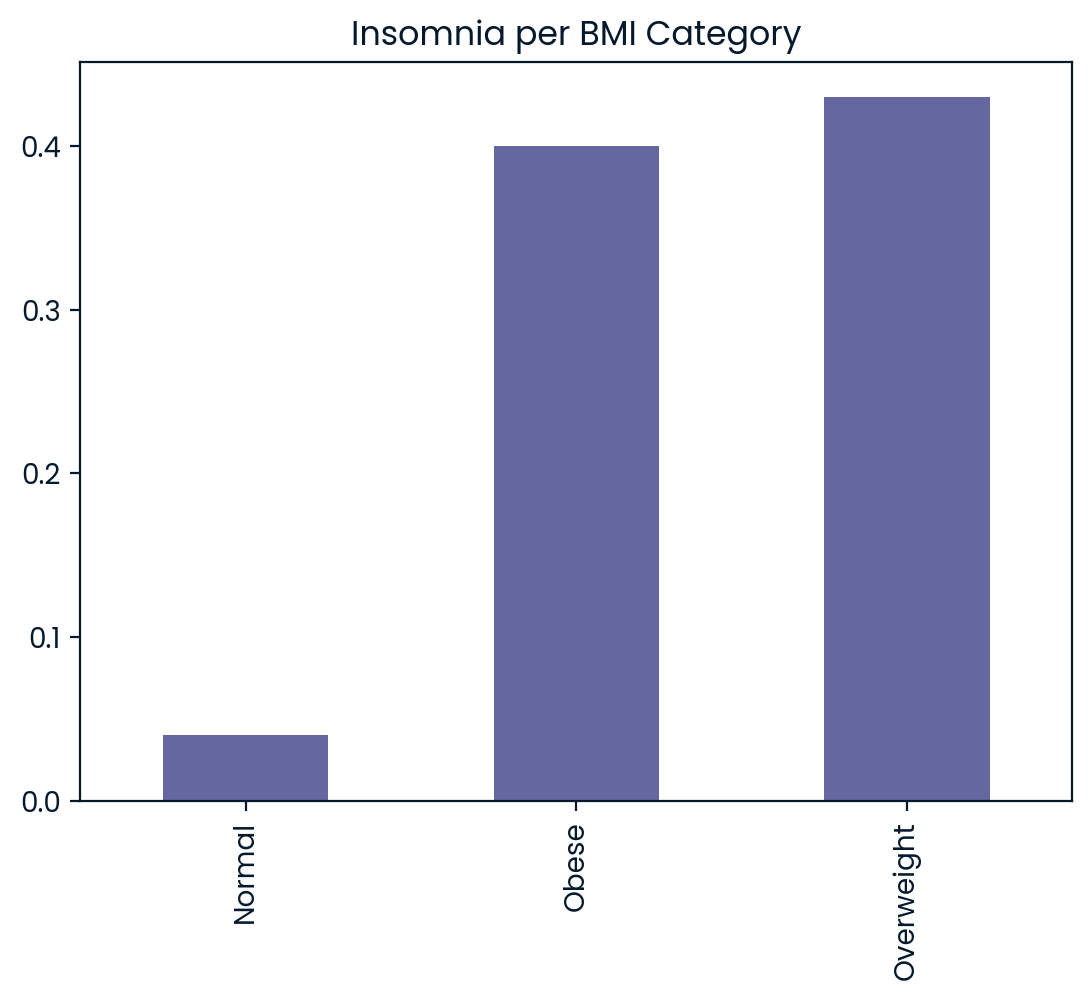

In [102]:
# Some Data Visualizations for fun - Part 3

bmi_insomnia_ratio.plot(kind='bar', x='BMI Category', y='insomnia_by_bmi', title="Insomnia per BMI Category")
plt.show()

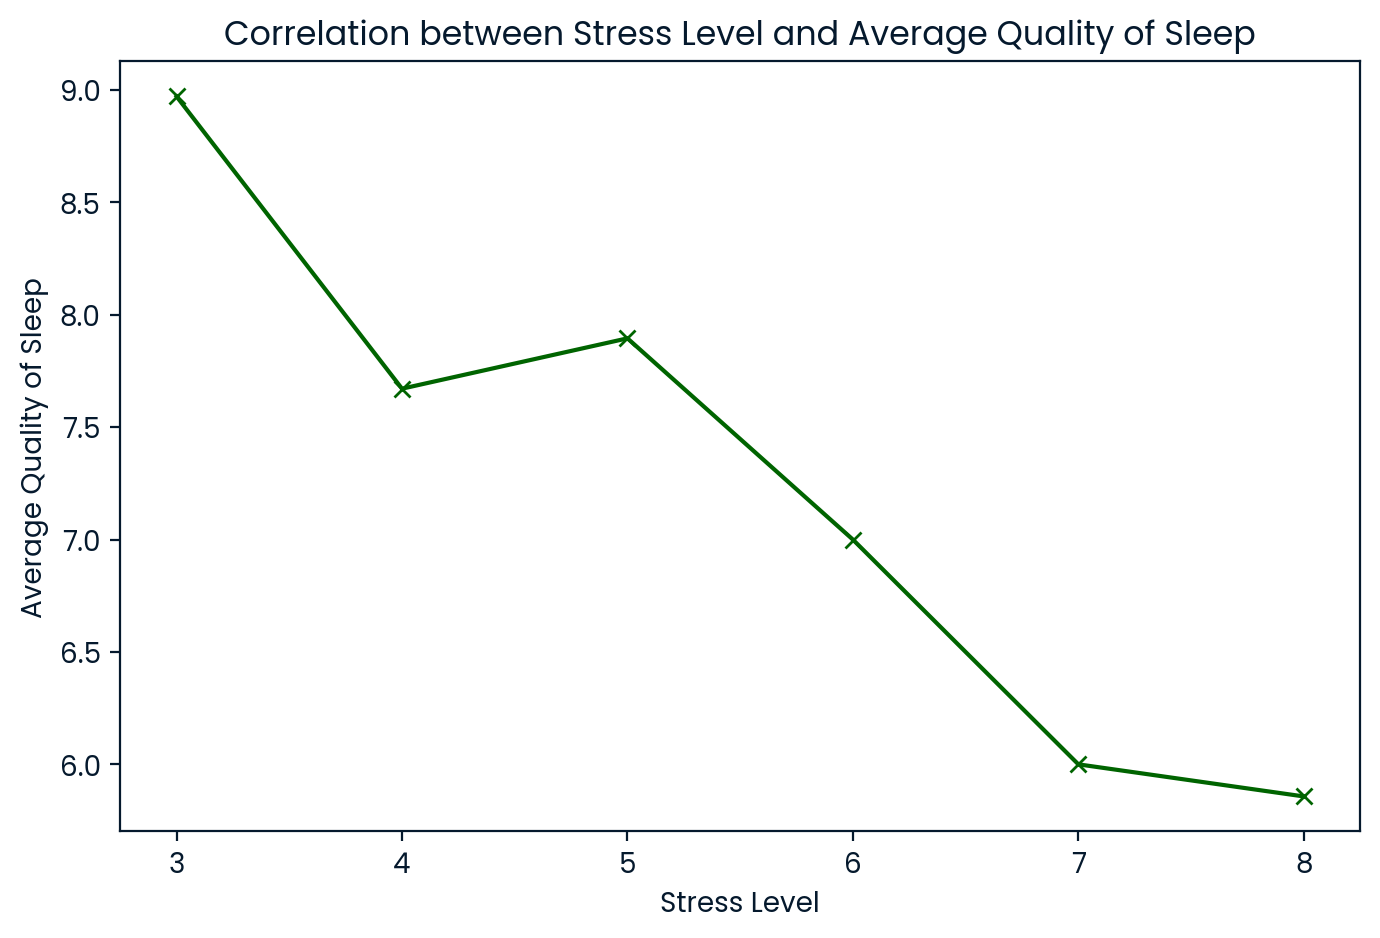

In [106]:
# Some Data Visualizations for fun - Part 3

stress_quality_trend_check = sleep_health_data.groupby('Stress Level')['Quality of Sleep'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(
        stress_quality_trend_check['Stress Level'],
        stress_quality_trend_check['Quality of Sleep'],
        marker='x',
        linestyle='-',
        color='darkgreen'
)
plt.title('Correlation between Stress Level and Average Quality of Sleep')
plt.xlabel('Stress Level')
plt.ylabel('Average Quality of Sleep')
plt.show()